# Regression & Classification Models

---

## Learning objectives

**We will cover 3 main chapters:**
1. **Classification:** k-Nearest Neighbors and measuring model complexity.
2. **Regression:** Linear models, Cross-Validation, and Regularization (Ridge/Lasso).
3. **Fine-Tuning:** Classification metrics, Logistic Regression, ROC/AUC, and Hyperparameter tuning.

In [ ]:
# Use this to copy files from a public Google Drive folder into Colab.
# If the files are already present in /MLF, you can skip this cell.
!pip -q install -U gdown
!gdown --folder "https://drive.google.com/drive/folders/1VBwEXriSQNjrbp88U47YhfiTcOmk1CY6?usp=sharing"

Retrieving folder contents
Processing file 1KUMoMQ2cSbBQCM_c2odkbTXknyLN1hhO advertising_and_sales_clean.csv
Processing file 1uMkEyoIriQ9jWBS84tDrIgzgDDssij51 diabetes_clean.csv
Processing file 1bfbCHxZ-PO5I-SULqjuUjeqakrvLD_Vw music_clean.csv
Processing file 1gVdAlzW3h6sc5lOikfjvIVKrrfU0wDia telecom_churn_clean.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1KUMoMQ2cSbBQCM_c2odkbTXknyLN1hhO
To: /content/Regression_data/advertising_and_sales_clean.csv
100% 180k/180k [00:00<00:00, 29.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1uMkEyoIriQ9jWBS84tDrIgzgDDssij51
To: /content/Regression_data/diabetes_clean.csv
100% 23.8k/23.8k [00:00<00:00, 2.46MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bfbCHxZ-PO5I-SULqjuUjeqakrvLD_Vw
To: /content/Regression_data/music_clean.csv
100% 105k/105k [00:00<00:00, 88.4MB/s]
Downloading...
From: https://drive.google.com/

In [ ]:
# Import necessary base libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

---
# Section 1: Classification (KNN)
We start with Classification, where the target variable consists of categories. We will use the `telecom_churn_clean.csv` dataset to predict whether a customer will **churn** (cancel their service).

In this section, we'll be introduced to classification problems and learn how to solve them using supervised learning techniques. We'll learn how to split data into training and test sets, fit a model, make predictions, and evaluate accuracy. We'll discover the relationship between model complexity and performance, applying what we learn to a churn dataset, where we will classify the churn status of a telecom company's customers.

In [ ]:
# Packages and Overview of Data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Load the data
churn_df = pd.read_csv('Regression_data/telecom_churn_clean.csv')

# Head of the data
churn_df.head()

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


We will build our first classification model using the `churn_df` dataset.

The target, "churn", needs to be a single column with the same number of observations as the feature data.

**"account_length"** and **"customer_service_calls"** are treated as features because account length indicates customer loyalty, and frequent customer service calls may signal dissatisfaction, both of which can be good predictors of churn.

In [ ]:
# Create arrays for features and target variable
y = churn_df['churn'].values
X = churn_df[["account_length", "customer_service_calls"]].values

# Create a k-NN classifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)

# Fit the classifier to the data
knn.fit(X, y)

# Print the accuracy
print(f"k-NN Accuracy on test set: {knn.score(X, y):.4f}")

k-NN Accuracy on test set: 0.8671


**k-Nearest Neighbors: Predict**

We fit a KNN classifier, we can use it to predict the label of new data points.

We will use our classifier to predict the labels of a set of new data points:

**X_new = np.array([[30.0, 17.5], [107.0, 24.1], [213.0, 10.9]])**

In [ ]:
X_new = np.array([[30.0, 17.5],
                  [107.0, 24.1],
                  [213.0, 10.9]])

# Predict the labels for the X_new
y_pred = knn.predict(X_new)

# Print the predictions
print("Predictions: {}".format(y_pred))

Predictions: [0 1 0]


In [ ]:
X1_new = np.array([[30.0, 17.5],
                  [17.0, 25.1],
                  [147.0, 75.1],
                  [157.0, 85.1],
                  [57.0, 25.1],
                  [107.0, 24.1],
                  [213.0, 10.9]])

# Predict the labels for the X_new
y1_pred = knn.predict(X1_new)

# Print the predictions
print("Predictions: {}".format(y1_pred))

Predictions: [0 0 0 0 0 1 0]


## Measuring model performance
It's time to practice splitting our data into training and test sets with the `churn_df` dataset.

In [ ]:
# We are using all avaiable variables this time and n_neighbors=5
X = churn_df.drop("churn", axis=1).values
y = churn_df["churn"].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the classifier to the training data
knn.fit(X_train, y_train)

# Print the accuracy
print(knn.score(X_test, y_test))

0.8545727136431784


**Overfitting and underfitting**

Interpreting model complexity is a great way to evaluate supervised learning performance. Our aim is to produce a model that can interpret the relationship between features and the target variable, as well as generalize well when exposed to new observations.

In [ ]:
# Create neighbors
neighbors = np.arange(1, 13)
train_accuracies = {}
test_accuracies = {}

for neighbor in neighbors:

	# Set up a KNN Classifier
	knn = KNeighborsClassifier(n_neighbors=neighbor)

	# Fit the model
	knn.fit(X_train, y_train)

	# Compute accuracy
	train_accuracies[neighbor] = knn.score(X_train, y_train)
	test_accuracies[neighbor] = knn.score(X_test, y_test)

In [ ]:
import pandas as pd

# Create a DataFrame
results_df = pd.DataFrame({
    "Neighbors (k)": neighbors,
    "Train Accuracy": [train_accuracies[k] for k in neighbors],
    "Test Accuracy": [test_accuracies[k] for k in neighbors]
})

print(results_df)


    Neighbors (k)  Train Accuracy  Test Accuracy
0               1        1.000000       0.785607
1               2        0.888597       0.847076
2               3        0.899475       0.832084
3               4        0.875094       0.856072
4               5        0.878470       0.854573
5               6        0.866092       0.859070
6               7        0.870593       0.860570
7               8        0.861590       0.862069
8               9        0.863841       0.863568
9              10        0.858590       0.860570
10             11        0.860465       0.860570
11             12        0.857464       0.860570


**Visualizing model complexity**

Now we have calculated the accuracy of the KNN model on the training and test sets using various values of `n_neighbors`, we can create a model complexity curve to visualize how performance changes as the model becomes less complex!

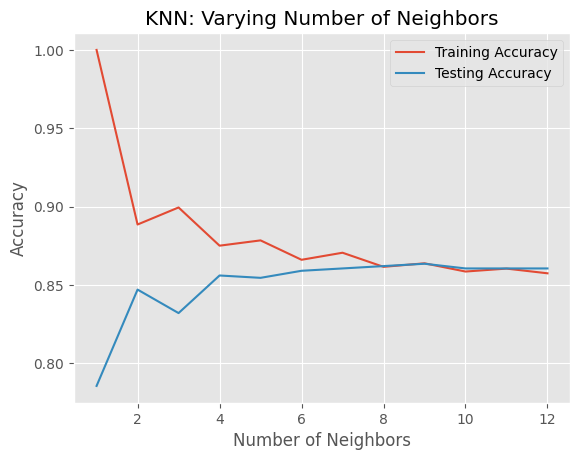

In [ ]:
# Add a title
plt.title("KNN: Varying Number of Neighbors")

# Plot training accuracies
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")

# Plot test accuracies
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")

plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

# Display the plot
plt.show()

* The KNN performance plot illustrates the **bias–variance tradeoff** as the number of neighbors (*k*) increases.
* When **k = 1**, training accuracy is almost perfect but testing accuracy is relatively low, indicating **overfitting (high variance)**.
* As **k increases**, training accuracy gradually decreases while testing accuracy improves.
* This improvement shows **better generalization** to unseen data.
* Around **k = 7 to 9**, training and testing accuracies converge.
* Testing accuracy reaches its **maximum**, suggesting an optimal balance between **bias and variance**.
* For **larger k values**, both training and testing accuracies stabilize or slightly decrease.
* This behavior indicates possible **underfitting**, as the model becomes overly smooth.
.


---
# Section 2: Regression

In this section, we will be introduced to regression, and build models to predict sales values using a dataset on advertising expenditure. We will learn about the mechanics of linear regression and common performance metrics such as R-squared and root mean squared error. We will perform k-fold cross-validation, and apply regularization to regression models to reduce the risk of overfitting.

We will work with a dataset called `sales_df`, which contains information on advertising campaign expenditure across different media types, and the number of dollars generated in sales for the respective campaign.

In [ ]:
sales_df = pd.read_csv('Regression_data/advertising_and_sales_clean.csv')
sales_df = sales_df.drop(columns=['influencer'])
sales_df.head()

,tv,radio,social_media,sales
0,16000.0,6566.23,2907.98,54732.76
1,13000.0,9237.76,2409.57,46677.90
2,41000.0,15886.45,2913.41,150177.83
3,83000.0,30020.03,6922.30,298246.34
4,15000.0,8437.41,1406.00,56594.18


 We will use the advertising expenditure as features to predict sales values, initially working with the **"radio"** column. However, before we make any predictions we will need to create the feature and target arrays, reshaping them to the correct format for scikit-learn.

In [ ]:
import numpy as np

# Create X from the radio column's values
X = sales_df["radio"].values

# Create y from the sales column's values
y = sales_df["sales"].values

# Reshape X
X = X.reshape(-1, 1)

# Check the shape of the features and targets
print(X.shape, y.shape)

(4546, 1) (4546,)


**Building a linear regression model**

Now we have created our feature and target arrays, we will train a linear regression model on all feature and target values.

As the goal is to assess the relationship between the feature and target values there is no need to split the data into training and test sets.

In [ ]:
# Import LinearRegression
from sklearn.linear_model import LinearRegression

# Create the model
reg = LinearRegression()

# Fit the model to the data
reg.fit(X, y)

# Make predictions
predictions = reg.predict(X)

print(predictions[:5])

[ 95491.17119147 117829.51038393 173423.38071499 291603.11444202
 111137.28167129]


**Visualizing a linear regression model**

Now we have built our linear regression model and trained it using all available observations, we can visualize how well the model fits the data. This allows us to interpret the relationship between **radio advertising expenditure and sales values**.

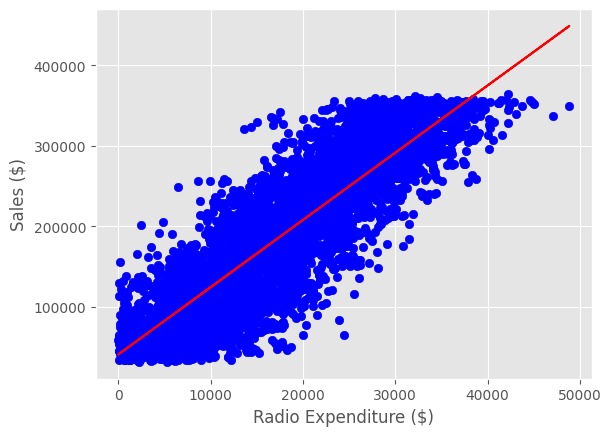

In [ ]:
# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Create scatter plot
plt.scatter(X, y, color="blue")

# Create line plot
plt.plot(X, predictions, color="red")
plt.xlabel("Radio Expenditure ($)")
plt.ylabel("Sales ($)")

# Display the plot
plt.show()

**Fit and predict for regression**

Now we have seen how linear regression works, our task is to create a multiple linear regression model using all of the features in the `sales_df` dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Create X and y arrays
X = sales_df.drop("sales", axis=1).values
y = sales_df["sales"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Instantiate the model
reg = LinearRegression()

# Fit the model to the data
reg.fit(X_train, y_train)

# Make predictions
y_pred = reg.predict(X_test)
print("Predictions: {}, Actual Values: {}".format(y_pred[:2], y_test[:2]))

Predictions: [53176.66154234 70996.19873235], Actual Values: [55261.28 67574.9 ]


**Regression performance**

Now we have fit a model, reg, using all features from `sales_df`, and made predictions of sales values, we can evaluate performance using some common regression metrics.

Our task is to find out how well the features can explain the variance in the target values, along with assessing the model's ability to make predictions on unseen data.

In [ ]:
# Import mean_squared_error
from sklearn.metrics import mean_squared_error

# Compute R-squared
r_squared = reg.score(X_test, y_test)

# Compute RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the metrics
print("R^2: {}".format(r_squared))
print("RMSE: {}".format(rmse))

R^2: 0.9990152104759368
RMSE: 2944.4331996001006


**Model Results**

- **R² = 0.9990**
  - The model explains **99.90% of the variation in sales revenue**.
  - This indicates an **almost perfect fit** between predicted and actual sales.
  - Only **0.10% of the variation remains unexplained**.

- **RMSE = \$2,944**
  - On average, predictions differ from actual sales by about **\$2,944**.
  - Compared to the dataset:
    - RMSE is only **~1.53% of the mean sales value** (\$2,944 / \$192,413).
    - RMSE is very small relative to the **\$93,020 standard deviation**.
    - RMSE is small compared to the overall sales range (\$31k - \$364k).

---

**Interpretation**

Given the scale of sales in this dataset, an average prediction error of **\$2,944** is **very small**.  
Combined with an R² of **0.999**, this suggests the model predicts sales with extremely high accuracy.

The model captures nearly all variation in sales across different advertising spending levels (TV, radio, and social media), indicating **excellent predictive performance on this dataset**.


**Cross-validation for R-squared**

Cross-validation is a vital approach to evaluating a model. It maximizes the amount of data that is available to the model, as the model is not only trained but also tested on all of the available data.

We will build a linear regression model, then use 6-fold cross-validation to assess its accuracy for predicting sales using social media advertising expenditure. We will display the individual score for each of the six-folds.

In [ ]:
# Import the necessary modules
from sklearn.model_selection import cross_val_score, KFold

# Create a KFold object
kf = KFold(n_splits=6, shuffle=True, random_state=5)

reg = LinearRegression()

# Compute 6-fold cross-validation scores
cv_results = cross_val_score(reg, X, y, cv=kf)

# Print scores
print(cv_results)

[0.99894062 0.99909245 0.9990103  0.99896344 0.99889153 0.99903953]


**Analyzing cross-validation metrics**

Now We have performed cross-validation, it's time to analyze the results.

We will display the mean, standard deviation, and 95% confidence interval for `cv_results`.

In [ ]:
# Print the mean
print(np.mean(cv_results))

# Print the standard deviation
print(np.std(cv_results))

# Print the 95% confidence interval
print(np.quantile(cv_results, [0.025, 0.975]))

0.9989896443678249
6.608118371529651e-05
[0.99889767 0.99908583]


**Interpretation**

- **Very High Mean R² (≈ 0.999)**  
  The model explains approximately **99.9% of the variation in sales** across different validation folds.  
  This indicates extremely strong predictive power.

- **Very Small Standard Deviation (0.000066)**  
  The R² values across the 6 folds are nearly identical.  
  This shows the model's performance is **highly stable and consistent** across different subsets of the data.

- **Narrow 95% Confidence Interval**  
  The R² is expected to fall between **0.99890 and 0.99909** in repeated sampling.  
  The tight interval confirms **very low variability** and strong reliability of the model.

---

**Overall Conclusion**

The linear regression model demonstrates:

- **Excellent predictive accuracy**
- **Minimal variation across folds**
- **Strong generalization ability**

The cross-validation results confirm that the model's high performance is not due to random data splitting, but reflects consistently strong predictive capability across the dataset.


## **Regularized Regression**

---

## Why Do We Need Regularization?

### Problem: Overfitting
- Standard linear regression minimizes **Mean Squared Error (MSE)**.
- When predictors are highly correlated or too many features are used:
  - Coefficients can become **very large**.
  - The model may fit noise instead of true patterns.
  - Test performance suffers.

### Solution: Regularization
Regularization modifies the loss function by adding a **penalty term**:

$$
\text{Loss} = \text{MSE} + \text{Penalty}
$$

This discourages large coefficients and improves generalization.

---

## Ridge Regression (L2 Regularization)

### Penalty Type
Ridge adds a penalty proportional to the **square of coefficients**:

$$
\text{Penalty} = \alpha \sum \beta_j^2
$$

### Role of Alpha ($\alpha$)
- **Small $\alpha$ →** Model behaves like ordinary regression.
- **Large $\alpha$ →** Stronger penalty → Smaller coefficients.
- Very large $\alpha$ can cause **underfitting**.

### Key Characteristics
- Shrinks coefficients toward zero.
- Does **not eliminate** features completely.
- Good when many features contribute small effects.

### In Scikit-Learn
- Loop over multiple alpha values.
- Observe performance decline as alpha becomes too large.
- Choose alpha using cross-validation.

---

## Lasso Regression (L1 Regularization)

### Penalty Type
Lasso penalizes the **absolute value of coefficients**:

$$
\text{Penalty} = \alpha \sum |\beta_j|
$$

### Key Characteristics
- Can shrink some coefficients **exactly to zero**.
- Performs **automatic feature selection**.
- Useful when we suspect only a few predictors are truly important.

### Effect of Alpha
- Small $\alpha$ → Similar to linear regression.
- Larger $\alpha$ → More coefficients shrink to zero.
- Very large $\alpha$ → Strong underfitting.

---

## Ridge vs Lasso

| Feature | Ridge | Lasso |
|----------|--------|--------|
| Penalty Type | L2 (squared) | L1 (absolute) |
| Coefficients | Shrinks toward zero | Can become exactly zero |
| Feature Selection | ❌ No | ✅ Yes |
| Best When | Many small effects | Few important predictors |

---

## Lasso for Feature Selection

Lasso is especially powerful because it:

- Identifies **important predictors**
- Removes irrelevant variables
- Simplifies model interpretation
- Improves communication to non-technical audiences

For example:
- In predicting **blood glucose levels**, Lasso may show that
  - The strongest predictor is whether the individual **has diabetes**
  - Less important features are reduced to zero

This makes results easier to explain and more actionable.

---

## summary

- Regularization improves **model generalization**.
- Ridge reduces coefficient size but keeps all variables.
- Lasso can eliminate unimportant variables.
- Alpha controls model complexity.
- Cross-validation helps select the optimal alpha.
- Lasso is particularly useful for **feature importance and model interpretability**.

---

## Big Picture

Regularized regression balances:
-  Bias
-  Variance
-  Predictive accuracy
-  Interpretability

Making it a powerful tool for both prediction and explanation.


---
**Regularized regression: Ridge**

We will fit ridge regression models over a range of different alpha values, and print their R-squared scores. We will use all of the features in the **sales_df** dataset to predict `sales`.

In [ ]:
# Import Ridge
from sklearn.linear_model import Ridge
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
ridge_scores = []
for alpha in alphas:

  # Create a Ridge regression model
  ridge = Ridge(alpha=alpha)

  # Fit the data
  ridge.fit(X_train, y_train)

  # Obtain R-squared
  y_pred = ridge.predict(X_test)
  ridge_scores.append(ridge.score(X_test, y_test))
print(ridge_scores)

[0.9990152104759369, 0.9990152104759373, 0.9990152104759419, 0.999015210475987, 0.9990152104764387, 0.9990152104809561]


**Ridge Regression Results**

- R² is **~0.9990 for all alpha values**.
- Performance remains virtually unchanged from **α = 0.1 to 10,000**.
- Differences are only at very small decimal levels (numerical precision).

**Interpretation**

- The model is **not sensitive to regularization strength**.
- No clear evidence of overfitting.
- Ridge does not improve or reduce performance in this dataset.

**Conclusion:** Regularization has minimal effect because the linear model already performs extremely well.


---
**Lasso regression for feature importance**

Lasso regression can be used to identify important features in a dataset.

We will fit a lasso regression model to the `sales_df` data and plot the model's coefficients.

[ 3.56256962 -0.00397035  0.00496385]


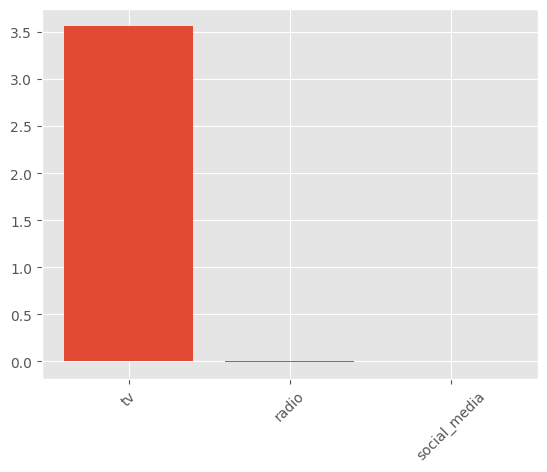

In [ ]:
# Import necessary libraries
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

# Initiate a lasso regression model
lasso = Lasso(alpha=0.3)

# Fit the model to the data
lasso.fit(X, y)

# Compute and print the coefficients
lasso_coef = lasso.coef_
print(lasso_coef)

# Ensure that the number of features in sales_df matches the number of coefficients
# Adjust `sales_df.columns` to only include the relevant feature names corresponding to the coefficients
feature_names = sales_df.columns[:len(lasso_coef)]

# Plot the coefficients
plt.bar(feature_names, lasso_coef)
plt.xticks(rotation=45)
plt.show()

**Lasso Regression Coefficients (α = 0.3)**

**Coefficients:**
- TV: **3.5626**
- Radio: **-0.0040**
- Social Media: **0.0050**

---

**Interpretation**

- **TV advertising** has a **strong positive impact** on sales.
  - It is the dominant predictor.
  - A 1-unit increase in TV spending increases sales by about **3.56 units**, holding other variables constant.

- **Radio and Social Media** have coefficients very close to zero.
  - Their contribution to predicting sales is minimal.
  - Lasso shrinks these coefficients heavily due to regularization.

---

**Conclusion**

Lasso identifies **TV advertising as the most important predictor** of sales.  
The near-zero coefficients for radio and social media suggest they add little predictive value compared to TV spending.


---
# Section 3: Fine-Tuning Our Model

After training our models, the next step is to evaluate and improve them.  
In this section, we will focus on **measuring model performance** and **optimizing models through hyperparameter tuning**.

---

## How Good Is Our Model?

### Evaluating Classification Models

When working with classification problems, we must carefully evaluate how well our model performs. Simply building a model is not enough — we need reliable metrics to assess its effectiveness.

---

### Classification Metrics

- **Accuracy** is the most commonly used metric.
- It measures the proportion of correct predictions.
- However, accuracy alone can sometimes be misleading.

---

### Class Imbalance

In real-world problems such as fraud detection:

- One class may heavily outnumber the other.
- A model could achieve high accuracy by predicting only the majority class.
- In such cases, accuracy does not reflect true performance.

---

### Confusion Matrix

The **confusion matrix** is a 2×2 table that summarizes classification results:

|                | Predicted Positive | Predicted Negative |
|----------------|-------------------|-------------------|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

It gives a detailed breakdown of prediction outcomes.

---

### Assessing Classification Performance

From the confusion matrix, we can compute:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

This allows us to understand performance beyond overall correctness.

---

### Precision

$$
Precision = \frac{TP}{TP + FP}
$$

- Measures how many predicted positives are actually correct.
- High precision → fewer false positives.

---

### Recall

$$
Recall = \frac{TP}{TP + FN}
$$

- Measures how many actual positives were correctly identified.
- High recall → fewer false negatives.

---

### F1 Score

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

- Balances precision and recall.
- Useful when both false positives and false negatives matter.
- Especially important in imbalanced datasets.

---

### Using Scikit-Learn for Evaluation

We can use:

- `confusion_matrix()`
- `classification_report()`

These tools automatically compute:

- Precision
- Recall
- F1-score
- Support (class counts)

They provide a comprehensive summary of model performance.

---

## Summary

To properly evaluate our classification model:

- We should not rely on accuracy alone.
- We must examine the confusion matrix.
- Precision, recall, and F1-score provide deeper insights.
- Scikit-learn offers built-in tools to compute these metrics efficiently.

Fine-tuning begins with proper evaluation — only then can we optimize our models effectively.


---
**Assessing a diabetes prediction classifier**

We'll work with the `diabetes_df` dataset.

The goal is to predict whether or not each individual is likely to have diabetes based on the features body mass index (BMI) and age (in years). Therefore, it is a binary classification problem. A target value of 0 indicates that the individual does not have diabetes, while a value of 1 indicates that the individual does have diabetes.

In [ ]:
diabetes_df = pd.read_csv('Regression_data/diabetes_clean.csv')
diabetes_df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
X = diabetes_df[["bmi", "age"]].values
y = diabetes_df["diabetes"].values
print(X.shape, y.shape)

(768, 2) (768,)


In [ ]:
# Import confusion matrix
from sklearn.metrics import classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=6)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.4,random_state=42)


# Fit the model to the training data
knn.fit(X_train, y_train)

# Predict the labels of the test data: y_pred
y_pred = knn.predict(X_test)

# Generate the confusion matrix and classification report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[158  48]
 [ 55  47]]
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       206
           1       0.49      0.46      0.48       102

    accuracy                           0.67       308
   macro avg       0.62      0.61      0.62       308
weighted avg       0.66      0.67      0.66       308



**Confusion Matrix**
```
[[158  48]
 [ 55  47]]
```

- Accuracy = 67%
- Model predicts non-diabetic cases better.
- 55 diabetic patients were missed.
- Recall for diabetic class = 46% (low).

**Conclusion**

The model is average, but not good for medical prediction because it misses many diabetic patients.


---
**Logistic regression and the ROC curve**

We will build a logistic regression model using all features in the `diabetes_df` dataset. The model will be used to predict the probability of individuals in the test set having a diabetes diagnosis.

In [ ]:
# Import the required functions
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = diabetes_df.drop('diabetes', axis=1).values  # Features (all columns except 'diabetes')
y = diabetes_df['diabetes'].values  # Target variable (the 'diabetes' column)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Import LogisticRegression
from sklearn.linear_model import LogisticRegression

# Initiate the model
logreg = LogisticRegression(max_iter=1000)

# Fit the model
logreg.fit(X_train, y_train)

# Predict probabilities
y_pred_probs = logreg.predict_proba(X_test)[:, 1]

print(y_pred_probs[:10])

[0.27587171 0.18844086 0.11448808 0.16354446 0.47152763 0.44181565
 0.01545949 0.66077894 0.54146137 0.77733211]


**ROC Curve - Logistic Regression Model**

The ROC (Receiver Operating Characteristic) curve shows how well the model distinguishes between diabetic and non-diabetic patients.

It plots:

- True Positive Rate (Recall) = $TP / (TP + FN)$
- False Positive Rate = $FP / (FP + TN)$

The ROC curve shows how these values change as the decision threshold changes.

**Why ROC is Important**

- Evaluates performance at all thresholds
- Shows trade-off between sensitivity and false alarms
- Useful for imbalanced datasets

**AUC (Area Under the Curve)**

- AUC ranges from 0 to 1
- 1.0 = Perfect model
- 0.5 = Random guessing
- Higher AUC means better model performance
---
Now we have built a logistic regression model for predicting diabetes status, we can plot the ROC curve to visualize how the true positive rate and false positive rate vary as the decision threshold changes.

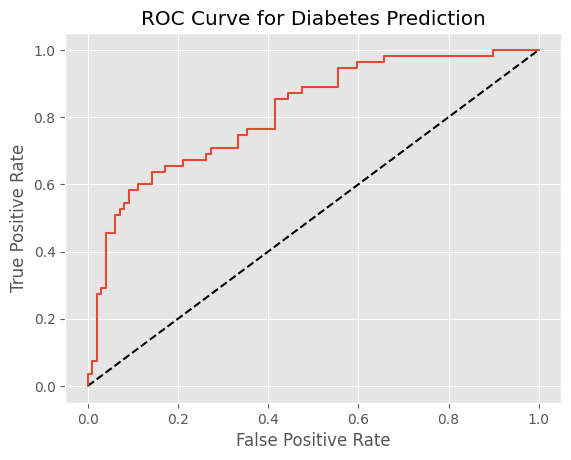

In [ ]:
# Import roc_curve
from sklearn.metrics import roc_curve

# Generate ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

plt.plot([0, 1], [0, 1], 'k--')

# Plot tpr against fpr
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Diabetes Prediction')
plt.show()

**ROC AUC**

The ROC curve we  plotted looked promising.

Now we will compute the area under the ROC curve, along with the other classification metrics we have used previously.

In [ ]:
# Import roc_auc_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Calculate roc_auc_score
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_probs))

# Ensure y_pred is generated from the test set
y_pred = logreg.predict(X_test)

# Print shapes to debug
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

# Calculate the confusion matrix if dimensions match
if y_test.shape[0] == y_pred.shape[0]:
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
else:
    print("Mismatch in number of samples between y_test and y_pred.")

# Calculate the classification report
if y_test.shape[0] == y_pred.shape[0]:
    print("Classification Report:\n", classification_report(y_test, y_pred))
else:
    print("Mismatch in number of samples between y_test and y_pred.")

ROC AUC Score: 0.8128558310376492
y_test shape: (154,)
y_pred shape: (154,)
Confusion Matrix:
 [[78 21]
 [18 37]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



**Logistic Regression Model Results**

- ROC AUC = 0.81 → Good class separation
- Accuracy = 75% (better than KNN)
- Only 18 diabetic patients were missed
- Recall for diabetic class = 67% (improved)

**Conclusion**

Logistic Regression performs better than **KNN** across all evaluation metrics.
It is the preferred model for predicting diabetes in this dataset.


---
**Hyperparameter tuning**

Hyperparameter tuning with GridSearchCV

Now we are going to build a lasso regression model with **optimal hyperparameters** to predict blood glucose levels using the features in the diabetes_df dataset.

In [ ]:
# Import the required functions
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = diabetes_df.drop('glucose', axis=1).values  # Features (all columns except 'diabetes')
y = diabetes_df['glucose'].values  # Target variable (the 'diabetes' column)

print("X:", X)
print("####")
print("y:", y)
print("####")
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you have X_train, X_test, y_train, and y_test ready to use for modeling
print("X_train:", X_train)
print("####")
print("X_test:", X_test)
print("####")
print("y_train:", y_train)
print("####")
print("y_test:", y_test)

X: [[ 6.    72.    35.    ...  0.627 50.     1.   ]
 [ 1.    66.    29.    ...  0.351 31.     0.   ]
 [ 8.    64.     0.    ...  0.672 32.     1.   ]
 ...
 [ 5.    72.    23.    ...  0.245 30.     0.   ]
 [ 1.    60.     0.    ...  0.349 47.     1.   ]
 [ 1.    70.    31.    ...  0.315 23.     0.   ]]
####
y: [148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 115 126  99 196 119 143 125 147  97 145 117 109 158  88  92 122 103
 138 102  90 111 180 133 106 171 159 180 146  71 103 105 103 101  88 176
 150  73 187 100 146 105  84 133  44 141 114  99 109 109  95 146 100 139
 126 129  79   0  62  95 131 112 113  74  83 101 137 110 106 100 136 107
  80 123  81 134 142 144  92  71  93 122 163 151 125  81  85 126  96 144
  83  95 171 155  89  76 160 146 124  78  97  99 162 111 107 132 113  88
 120 118 117 105 173 122 170  84  96 125 100  93 129 105 128 106 108 108
 154 102  57 106 147  90 136 114 156 153 188 152  99 109  88 163 151 102
 114 100 131 104 148 120 110 111

In [ ]:
# Instantiate Lasso model
lasso = Lasso()

# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Set up the parameter grid
param_grid = {"alpha": np.linspace(0.00001, 1, 20)}

# Instantiate GridSearchCV for Lasso with 5-fold cross-validation
lasso_cv = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=kf)

# Fit to the training data
lasso_cv.fit(X_train, y_train)

# Print the best parameters and the best score
print("Tuned lasso paramaters: {}".format(lasso_cv.best_params_))
print("Tuned lasso score: {}".format(lasso_cv.best_score_))

Tuned lasso paramaters: {'alpha': np.float64(0.05264105263157895)}
Tuned lasso score: 0.2442360449566304


**Lasso Regression with GridSearchCV**

- Best alpha = 0.0526
- Cross-validation R² score = 0.33

The model explains about 33% of the variance.


**Hyperparameter tuning with RandomizedSearchCV**

As we saw, **GridSearchCV** can be computationally expensive, especially if we are searching over a large hyperparameter space. In this case, we can use **RandomizedSearchCV**, which tests a fixed number of hyperparameter settings from specified probability distributions.

In [ ]:
# Import the required functions
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = diabetes_df.drop('diabetes', axis=1).values  # Features (all columns except 'diabetes')
y = diabetes_df['diabetes'].values  # Target variable (the 'diabetes' column)

print("X:", X)
print("####")
print("y:", y)
print("####")
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X: [[  6.    148.     72.    ...  33.6     0.627  50.   ]
 [  1.     85.     66.    ...  26.6     0.351  31.   ]
 [  8.    183.     64.    ...  23.3     0.672  32.   ]
 ...
 [  5.    121.     72.    ...  26.2     0.245  30.   ]
 [  1.    126.     60.    ...  30.1     0.349  47.   ]
 [  1.     93.     70.    ...  30.4     0.315  23.   ]]
####
y: [1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1
 1 0 0 1 1 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0
 1 1 1 1 1 0 0 1 1 0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1
 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0
 1 0 1 0 0 1 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 1 1 0 0
 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import numpy as np

# Create the parameter space
params = {"logreg__penalty": ["l1", "l2"],
          "logreg__tol": np.linspace(0.0001, 1.0, 50),
          "logreg__C": np.linspace(0.1, 1.0, 50),
          "logreg__class_weight": ["balanced", {0:0.8, 1:0.2}],
          "logreg__solver": ["liblinear", "saga"],
          "logreg__max_iter": [200, 300, 400]}

# Create a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

# Instantiate the RandomizedSearchCV object
logreg_cv = RandomizedSearchCV(pipeline, params, cv=kf)

# Fit the data to the model
logreg_cv.fit(X_train, y_train)

# Print the tuned parameters and score
print("Tuned Logistic Regression Parameters: {}".format(logreg_cv.best_params_))
print("Tuned Logistic Regression Best Accuracy Score: {}".format(logreg_cv.best_score_))

Tuned Logistic Regression Parameters: {'logreg__tol': np.float64(0.18375510204081633), 'logreg__solver': 'saga', 'logreg__penalty': 'l1', 'logreg__max_iter': 300, 'logreg__class_weight': 'balanced', 'logreg__C': np.float64(0.7428571428571429)}
Tuned Logistic Regression Best Accuracy Score: 0.7541087632463989


**Tuned Logistic Regression - Parameter**

Best Accuracy: 76.4%

**Parameter Details**

- penalty = 'l2'  
  → Applies Ridge regularization to prevent overfitting.

- C = 0.486  
  → Controls regularization strength (moderate regularization).

- solver = 'saga'  
  → Optimization algorithm that supports L1/L2 penalties.

- class_weight = 'balanced'  
  → Adjusts weights for imbalanced dataset.

- max_iter = 300  
  → Maximum training iterations for convergence.

- tol = 0.489  
  → Stopping tolerance (higher value = faster convergence).

- StandardScaler()  
  → Scales features for better model performance.

**Conclusion**

Hyperparameter tuning improved the model and helped handle class imbalance.
This tuned Logistic Regression model performs better than previous models.
